In [2]:
import numpy as np
import cv2
import json
from typing import List
import re
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
from PIL import Image
import io
import html
import base64
from IPython.display import display, HTML

def read_n_lines(file_path: str, n: int) -> List[str]:
    with open(file_path, 'r') as file:
        lines = [next(file).strip() for _ in range(n)]
    return lines

def parse_trajectory_tokens(caption):
  caption = caption.strip("\n")
  if ";" in caption:
    raise ValueError
  pattern = r"(?:<loc\d{4}>)+ ([\w\s\-]+)$"
  match = re.search(pattern, caption)
  #print(f"Matched words: {match.group(1)}")
  if match:
    return match
  else:
    return ""

images = []
lines = read_n_lines(f"{dataset_location}/dataset/_annotations.all.jsonl.small", 2)
first = json.loads(lines[0])

#CLASSES = first.get('prefix').replace("detect ", "").split(" ; ")
for line in lines:
    data = json.loads(line)
    #image = cv2.imread(f"{dataset_location}/dataset/{data.get('image')}")
    #(h, w, _) = image.shape

    suffix = data.get('suffix')
    prefix = data.get('prefix')
    #match = parse_trajectory_tokens(suffix)
    print(prefix)
    

move large blue cube onto large blue sphere<loc0406><loc0482><loc0053><loc0101><loc0051><loc0083>
move small purple sphere onto small brown sphere<loc0409><loc0510><loc0050><loc0104><loc0048><loc0076>


In [1]:
import numpy as np
import cv2
import json
from typing import List
import re
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
from PIL import Image
import io
import html
import base64
from IPython.display import display, HTML

In [6]:
from droidloader.my_episode_list import date_to_uuid, annotations, imginfo
from droidloader.max_loader import MaxLoader

EPISODE_IDX = 0
loader = MaxLoader(True)
print("number of episodes:", len(loader))
print("Shuffled episode #0")
print("annotation:", loader.get_annotation(EPISODE_IDX))
print("intrinsic:")
print(loader.get_intrinsic(EPISODE_IDX))
#print("start and stop point:")
#print(loader.get_start_stop_point(0))
print("first image:")
imginfo(loader.get_image_0(EPISODE_IDX))

print("first tcp:")
print(loader.get_tcp_0(EPISODE_IDX))

[0, 1, 2, 3, 4]
number of episodes: 5
Shuffled episode #0
annotation: Stack the cups into the orange cup
intrinsic:
[[524.4229126    0.         639.77502441]
 [  0.         524.4229126  370.27749634]
 [  0.           0.           1.        ]]
first image:
<class 'numpy.ndarray'> float32 (720, 1280, 3) 0.0 1.0
first tcp:
[[ 5.02250425e-16 -1.44297932e-15 -3.49998896e-01  3.72594793e-01]
 [ 7.82169479e-16 -2.80036391e-16  8.58693432e-01  1.67723956e-01]
 [-1.31257934e-15 -7.01854349e-16  3.74361273e-01  6.43936187e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


[[-5.76363847e-13 -1.20576030e-12  5.59595519e+01  6.07371537e+02]
 [-7.58309946e-14 -4.06738371e-13  5.88936065e+02  3.26393365e+02]
 [-1.31257934e-15 -7.01854349e-16  3.74361273e-01  6.43936187e-01]]
O [943.21696569 506.87222028]
X [943.21696569 506.87222028]
Y [943.21696569 506.87222028]
Z [899.60727604 565.45733263]



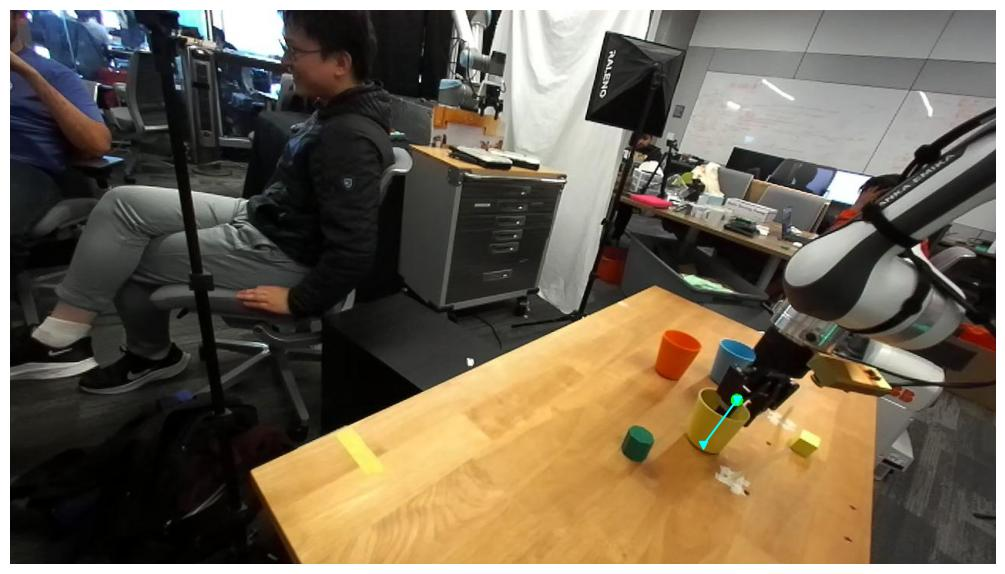

done!


In [7]:
# text = "<loc0625><loc0762><loc0468><loc0724><loc0384><loc0679><loc0375><loc0632><loc0430><loc0587><loc0587> 1"
# action_text = data.get('prefix')

def camera_to_world(t, rot):
    """
    Extrinsic matrix C from local coordinates to world coordinates.
    First rotation, then translation.
    t: (3) translation, world coordinates of local center
    rot: (3,3) rotation
    """
    ext = np.eye(4)
    ext[0:3, 0:3] = rot
    ext[0:3, 3] = t
    return ext

def world_to_camera(t: np.ndarray, rot: np.ndarray):
    """
    World 3d to camera 3d.
    t: (3) translation
    rot: (3,3) rotation
    """
    ext = np.eye(4)
    ext[0:3, 0:3] = rot.T
    ext[0:3, 3] = -rot.T @ t
    return ext

def project(point_3d: np.ndarray, proj: np.ndarray):
    """ 
    Multiply projection matrix by point in homogenous coordinates.
    point_3d: (3) 
    proj: (3, 4) """
    p3d = np.ones((4))
    p3d[:3] = point_3d
    p2d = proj @ p3d # (3, 4) x (4, 1)
    p2d = p2d / p2d[2]
    return p2d[:2]

# === Project world to pixels:
# 1) world to camera, C^(-1)
# 2) pinhole
# 3) intrinsic
# 4) divide by last component in homogeneous coordinates

# === Camera
extrinsic = np.eye(4)
intrinsic = loader.get_intrinsic(EPISODE_IDX)
pinhole = np.eye(4)[:3, :4]
camera_proj = intrinsic @ pinhole @ extrinsic # (3, 3) x (3, 4), x (4, 4)

# === Robot extrinsic = [tx ty tz + qw qx qy qz]
robot_transform = loader.get_tcp_0(EPISODE_IDX)

def render_example_trajectory(image, caption):
    image_height = 720 # 448, 448
    image_width = 1280
    
    # === Pattern to extract numbers inside <loc####> tags
    # loc_strings = re.findall(r"<loc(\d{4})>", caption)
    # num_position_tokens = len(loc_strings)
    # loc_strings_pairs = loc_strings[:(num_position_tokens//2)*2]
    # loc_numbers = [int(x) for x in loc_strings_pairs]
    # loc_h = [x/1024*image_height for x in loc_numbers[::2]]
    # loc_w = [x/1024*image_width for x in loc_numbers[1::2]]
    # curve_2d_short = curve_2d = np.array([np.stack((loc_w, loc_h), axis=1)])

    # env_id = 0
    # x, y = curve_2d[env_id, :, 0].tolist(), curve_2d[env_id, :, 1].tolist()

    dpi = 100
    figsize = (image_width / dpi, image_height / dpi)
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.imshow(image)
    ax.axis('off')
    #ax.plot(curve_2d_short[env_id,:1,0], curve_2d_short[env_id, :1,1],'.-', color='lime')
    
    # === plot coordinate system (robot space)
    axes_length = 0.1
    o = np.array([0, 0, 0])
    x = np.array([1, 0, 0]) * axes_length
    y = np.array([0, 1, 0]) * axes_length
    z = np.array([0, 0, 1]) * axes_length
    total_proj = camera_proj @ robot_transform

    o = project(o, total_proj)
    x = project(x, total_proj)
    y = project(y, total_proj)
    z = project(z, total_proj)
    print(total_proj)
    print("O", o)
    print("X", x)
    print("Y", y)
    print("Z", z)
    
    line_x = np.stack((o, x)) # (n_points, xy)
    line_y = np.stack((o, y))
    line_z = np.stack((o, z))
    ax.plot(line_x[:, 0], line_x[:, 1],'v-', color='tomato')
    ax.plot(line_y[:, 0], line_y[:, 1],'v-', color='lime')
    ax.plot(line_z[:, 0], line_z[:, 1],'v-', color='aqua')

    with io.BytesIO() as buffer:
        fig.savefig(buffer, format='jpeg',bbox_inches='tight', dpi=dpi)
        image_b64 = str(base64.b64encode(buffer.getvalue()), "utf-8")
        res_str =  f"data:image/jpeg;base64,{image_b64}"
    plt.close(fig)
    
    # width, height = 224, 224
    return f"""
<div style="display: inline-flex; align-items: center; justify-content: center;">
    <img style="width:640px; height:360px;" src="{res_str}" />
    <p style="width:256px; margin:10px; font-size:small;">{html.escape(caption)}</br>{html.escape(caption)}</p>

</div>
"""

html_out = ""
#for image, _, caption in make_predictions(validation_data_iterator(), num_examples=1, batch_size=1):
#  html_out += render_example(image, caption)

caption = loader.get_annotation(EPISODE_IDX)
image = loader.get_image_0(EPISODE_IDX)
html_out += render_example_trajectory(image, caption)
display(HTML(html_out))
print("done!")

In [13]:
matches[:, 0]

NameError: name 'matches' is not defined